# **Importing packages** 

In [15]:

# Importing libarires 

library("igraph")

## **Reading input files**

In [16]:
list.files("/kaggle/input/datasets/aysuserkerova/facebook-artist-pages-graph-dataset")

[1] "fb-pages-artist.edges" "fb-pages-artist.nodes"

In [17]:
# Reading the graph from the file into an edge list
edges <- read.csv("/kaggle/input/datasets/aysuserkerova/facebook-artist-pages-graph-dataset/fb-pages-artist.edges", header = FALSE, col.names = c("from", "to"))
nodes <- read.csv("/kaggle/input/datasets/aysuserkerova/facebook-artist-pages-graph-dataset/fb-pages-artist.nodes", header = TRUE)

# Creating the graph from the edge list
g <- graph_from_data_frame(edges, directed = FALSE)

## **Graph properties**

In [18]:
cat("Vertices:", vcount(g), "\n")
cat("Edges:", ecount(g), "\n")
cat("Density:", format(edge_density(g), scientific = FALSE), "\n")
cat("Maximum degree:", max(igraph::degree(g)), "\n")
cat("Average degree:", round(mean(igraph::degree(g)), 2), "\n")
cat("Minimum degree:", min(igraph::degree(g)), "\n")

Vertices: 50515 
Edges: 819306 
Density: 0.0006421611 
Maximum degree: 1469 
Average degree: 32.44 
Minimum degree: 1 


## **Simplyfing the graph**

In [19]:
# running simplify() on g, removes duplicate edges and loops
g <- simplify(g, remove.multiple = TRUE, remove.loops = TRUE)

cat("Vertices (post simplify() method):", vcount(g),"\nEdges (post simplify() method):", ecount(g), "\n")

# removing vertices with degree less than 3
for (i in 1:4) {
  g <- delete_vertices(g, V(g)[degree(g) < 3])
}
cat("\nVertices (post degree filtering):", vcount(g),"\nEdges (post degree filtering):", ecount(g), "\n")

Vertices (post simplify() method): 50515 
Edges (post simplify() method): 819090 

Vertices (post degree filtering): 43879 
Edges (post degree filtering): 809154 


# **5. Graph Analytics**

### **(a) Central Nodes**

#### **Degree Centrality**

Degree centrality measures the number of connections each node has in the network.
Nodes with many connections are considered central nodes, because they interact with many other nodes.

In this dataset, nodes represent Facebook artist pages, so nodes with high degree centrality are pages that are connected to many other artist pages.

In [20]:
# Calculate degree centrality for each node
# Degree = number of edges connected to a node
centrality <- degree(g)

# Sort nodes by degree (highest first)
# Select the top 10 most connected nodes
top_nodes <- sort(centrality, decreasing = TRUE)[1:10]

# Display results
top_nodes

7675 41998 48099  9187 37078 13455  6970 37439 31746  3875 
 1464  1457  1325  1315  1295  1239  1225  1222  1207  1206

This code finds the most connected artists in the network and these artists act like hubs in the network.

### **(b) Longest Path**

#### **Longest Path (Graph Diameter)**

The longest path in a graph is called the diameter.
It represents the largest shortest distance between any two nodes in the network.

This helps us understand how far information or connections can spread across the network

In [21]:
# Calculate the diameter of the graph
# Diameter = longest shortest path between two nodes
diameter_value <- diameter(g)

diameter_value

[1] 8

In [22]:
# Get the nodes forming the longest path
longest_path <- get_diameter(g)

longest_path

+ 9/43879 vertices, named, from 19408b5:
[1] 690   24713 28522 11586 25553 22826 8315  29669 29931

### **(c) Largest Clique**

#### **Clique Detection**

A clique is a group of nodes where every node is connected to every other node.

The largest clique represents a tightly connected community where all members interact with each other.

In [23]:
# Find largest cliques in the graph
largest_cliques_list <- largest_cliques(g)

largest_cliques_list

[[1]]
+ 18/43879 vertices, named, from 19408b5:
 [1] 4251  561   40733 34318 33622 30194 23986 16097 10896 41231 37724 48568
[13] 41046 37456 23141 6068  6501  23781

[[2]]
+ 18/43879 vertices, named, from 19408b5:
 [1] 4251  561   40733 34318 33622 30194 23986 16097 10896 41231 37724 48568
[13] 41046 37456 23141 6068  6501  27455

[[3]]
+ 18/43879 vertices, named, from 19408b5:
 [1] 32857 4441  25387 23612 43858 4294  22977 5140  33750 33602 23607 44280
[13] 24478 34320 11413 43329 30362 25255

[[4]]
+ 18/43879 vertices, named, from 19408b5:
 [1] 32857 4441  25387 23612 43858 4294  22977 5140  33750 33602 23607 44280
[13] 24478 34320 11413 43329 38351 2235 

[[5]]
+ 18/43879 vertices, named, from 19408b5:
 [1] 32857 4441  25387 23612 43858 4294  22977 5140  33750 33602 23607 44280
[13] 24478 34320 11413 43329 38351 9856 

[[6]]
+ 18/43879 vertices, named, from 19408b5:
 [1] 32857 4441  25387 23612 43858 4294  22977 5140  33750 33602 23607 44280
[13] 24478 34320 11413 43329 38351 25255

### **(d) Ego Networks**

#### **Ego Network**

An ego network shows a node and its immediate neighbors.

It helps us analyze the local neighborhood around an important node.

In [24]:
# Select one central node (for example the most connected node)
ego_node <- names(top_nodes)[1]

# Extract ego network (neighbors within distance 1)
ego_network <- ego(g, order = 1, nodes = ego_node)

ego_network

[[1]]
+ 1465/43879 vertices, named, from 19408b5:
   [1] 7675  9     31    33    33041 130   160   234   263   281   282   300  
  [13] 365   16399 390   24659 473   497   498   549   615   663   776   829  
  [25] 840   889   914   25028 947   1051  24768 1103  1123  1132  24777 1180 
  [37] 1217  24796 1281  1308  1324  1455  1460  1470  50413 1497  1586  50299
  [49] 33354 1809  1821  1844  1859  1967  1972  1974  1999  2000  2007  2020 
  [61] 24942 27020 2144  2147  2165  2191  2193  2195  2222  2243  2248  2312 
  [73] 42054 2396  2399  2407  2413  2449  2453  2493  2560  2629  2650  2655 
  [85] 2745  2781  2811  2815  2863  2867  2878  2912  2976  2978  25120 3046 
  [97] 3123  3134  3169  3187  3217  3272  3293  3310  3359  3414  3426  3452 
 [109] 3482  3522  3605  603   23991 44735 3749  46447 3792  3913  48049 4030 
+ ... omitted several vertices


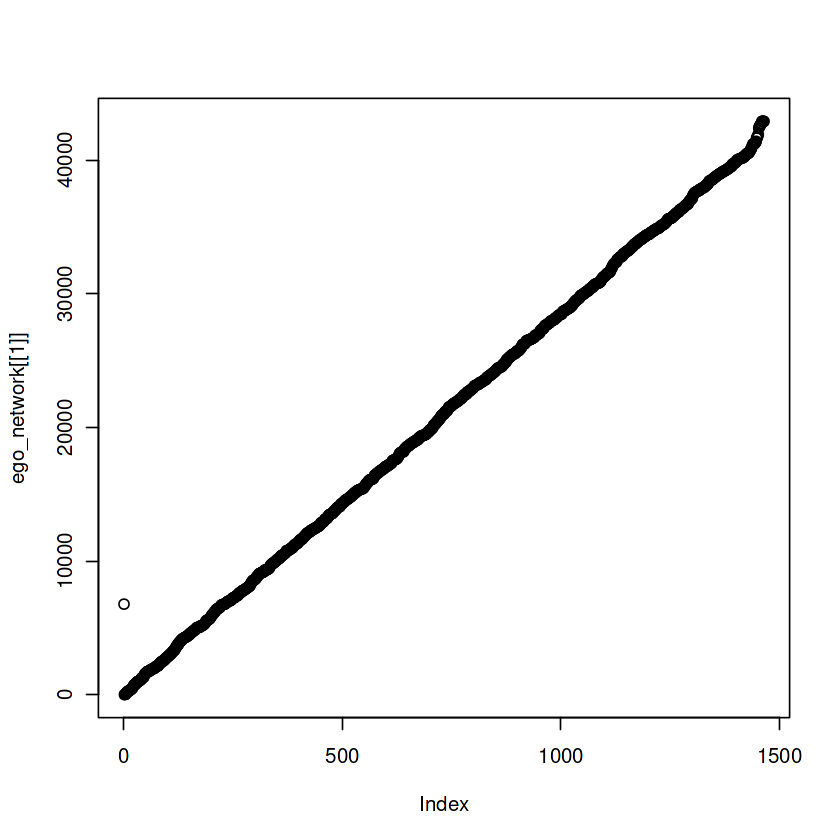

In [25]:
plot(ego_network[[1]])

### **(e) Power Centrality**

#### **Power Centrality**

Power centrality measures how influential a node is, considering both:
	•	its direct connections
	•	how important its neighbors are

Nodes connected to other influential nodes will have higher power centrality.

In [26]:
library(sna)
library(intergraph)

# Convert igraph graph to network format
g_net <- asNetwork(g)

# Compute power centrality
power_cent <- power_centrality(g_net)

# Show top 10 influential nodes
top_power <- sort(power_cent, decreasing = TRUE)[1:10]

top_power

Loading required package: statnet.common


Attaching package: ‘statnet.common’


The following objects are masked from ‘package:base’:

    attr, order


Loading required package: network


‘network’ 1.18.2 (2023-12-04), part of the Statnet Project
* ‘news(package="network")’ for changes since last version
* ‘citation("network")’ for citation information
* ‘https://statnet.org’ for help, support, and other information



Attaching package: ‘network’


The following objects are masked from ‘package:igraph’:

    %c%, %s%, add.edges, add.vertices, delete.edges, delete.vertices,
    get.edge.attribute, get.edges, get.vertex.attribute, is.bipartite,
    is.directed, list.edge.attributes, list.vertex.attributes,
    set.edge.attribute, set.vertex.attribute


sna: Tools for Social Network Analysis
Version 2.7-2 created on 2023-12-05.
copyright (c) 2005, Carter T. Butts, University of California-Irvine
 For citation information, type citation("sna").
 Type help(package="sna") to get started.


ERROR: [1m[33mError[39m in `ensure_igraph()`:[22m
[1m[22m[33m![39m Must provide a graph object (provided wrong object type).


We may explain this phenomenon as : <br>
Degree centrality = **how many friends you have**

Power centrality = **how powerful your friends are**

Artist A connected to **10** famous artists <br>
Artist B connected to **20** unknown artists <br>
Thus, **Artist A** might have higher power centrality.

### **(f) Community Detection**

### **Community Detection**

Communities are groups of nodes that are more connected to each other than to the rest of the network.

In this dataset, communities may represent clusters of artists with strong relationships.

We use the Louvain algorithm, which is widely used for detecting communities in large graphs

In [ ]:
# Detect communities using Louvain algorithm
communities <- cluster_louvain(g)

# Show community membership
membership(communities)

In [ ]:
plot(communities, g)

## **Summary**

Graph analytics techniques help identify important nodes, structural properties, and clusters within the network.
Degree centrality reveals the most connected nodes, diameter shows the longest distance across the graph, cliques highlight tightly connected groups, ego networks examine local neighborhoods, power centrality identifies influential nodes, and community detection reveals clusters of related nodes in the network.

In [2]:
system('git config --global user.email "aysuserkerova9@gmail.com"')
system('git config --global user.name "AysuSerkerova0625"')

In [4]:
system("git clone https://github.com/ilpalazz0/Big-Data-Assignment-1.git")
setwd("Big-Data-Assignment-1")

In [5]:
system("git checkout -b Aysu")

In [8]:
system("cp /kaggle/working/*.ipynb .")

In [9]:
list.files()

[1] "README.md"

In [11]:
system("git add .")
system('git commit -m "5th Task"')